# Análisis Exploratorio: Mercado Eléctrico Español (Series Temporales)

## 1. Contexto y Objetivo
Este análisis audita el comportamiento del mercado eléctrico español entre 2014 y 2018,
utilizando datos horarios del operador del sistema (Red Eléctrica de España).
El dataset contiene múltiples métricas energéticas identificadas por ID — precio SPOT,
demanda real y generación por fuente — mezcladas en una estructura longitudinal que
requiere aislamiento previo de cada señal antes de cualquier análisis.

El objetivo es identificar los factores que determinan el precio de la energía,
con foco especial en la relación entre la generación renovable y el costo del mercado.

> **Orden de Mérito**: en el mercado eléctrico, las fuentes de energía se despachan
> de menor a mayor costo marginal. Las renovables (eólica, solar) tienen costo marginal
> casi cero, por lo que entran primero. Cuando generan mucho, desplazan fuentes más caras
> y el precio final del mercado baja. Esa es la hipótesis central que este análisis busca
> confirmar o refutar.

## 2. Resumen Ejecutivo
* **Tendencia de precios volátil**: el precio SPOT muestra alta variabilidad inter-anual,
  con períodos de precios bajos sostenidos que coinciden con alta generación renovable.
* **Demanda relativamente estable**: la demanda energética total no fluctúa tanto como
  el precio, lo que sugiere que la oferta (no el consumo) es el principal driver del precio.
* **El viento mueve el precio**: la generación eólica tiene correlación negativa con el
  precio SPOT — más viento produce energía más barata. Es la relación más fuerte del dataset.

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

#configuracion inicial de librerias para graficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

#ruta local para desarrollo, ruta kaggle para produccion
if os.path.exists("/kaggle/input"):
    data_path = "/kaggle/input/spanish-electricity-market-demand-gen-price/spain_energy_market.csv"
else:
    data_path = "../data/raw/spain_energy_market.csv"
df_energia = pd.read_csv(data_path,parse_dates=["datetime"]) #parsear la columna de fecha
df_energia = df_energia.set_index("datetime") #poner fecha como indice para utilizar como eje temporal

print("Estructura temporal inicial:")
df_energia.info()
display(df_energia.head())


Estructura temporal inicial:
<class 'pandas.DataFrame'>
DatetimeIndex: 40212 entries, 2014-01-01 23:00:00 to 2018-12-31 23:00:00
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       40212 non-null  int64  
 1   name     34734 non-null  str    
 2   geoid    10956 non-null  float64
 3   geoname  10956 non-null  str    
 4   value    40212 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.8 MB


,id,name,geoid,geoname,value
datetime,,,,,
2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500


## Análisis de Metadatos y Diccionario de Variables
Inspección de las columnas categóricas (`geoname` y `name`) para identificar zonas geográficas involucradas y evaluar la viabilidad de reconstruir los nombres faltantes a través del `id`.

In [17]:
#que zonas existen y cuantos datos tienen?
print('Regiones Geograficas detectadas (geoname)')
print(df_energia['geoname'].value_counts(dropna=False))

#se puede usar el ID para rescatar los nombres?
print("Mapeo de ID vs Name")
#agrupar por id y contar valores unicos
mapeo_id_name = df_energia.groupby('id')['name'].unique()
print(mapeo_id_name)

Regiones Geograficas detectadas (geoname)
geoname
NaN         29256
España       3652
Francia      3652
Portugal     3652
Name: count, dtype: int64
Mapeo de ID vs Name
id
3           [Generación programada PBF Turbinación bombeo]
4                      [Generación programada PBF Nuclear]
9              [Generación programada PBF Ciclo combinado]
14          [Generación programada PBF Solar fotovoltaica]
17       [Generación programada PBF Gas Natural Cogener...
600      [Precio mercado SPOT Diario ESP, Precio mercad...
602       [Energía asignada en Mercado SPOT Diario España]
1117     [Rentas de congestión mecanismos implícitos di...
1118     [Rentas de congestión mecanismos implícitos di...
1119     [Rentas de congestión mecanismos implícitos di...
1120     [Rentas de congestión mecanismos implícitos di...
1293                                        [Demanda real]
1334     [Energía asignada en Mercado SPOT Diario Francia]
10064             [Generación programada PBF UGH + no UGH]
100

## Aislamiento de Señales Temporales Críticas
Filtrado transversal del dataset para extraer y separar las series temporales puras correspondientes al precio de mercado (España) y la demanda energética total, eliminando el ruido de métricas secundarias y fronterizas.

In [18]:
#extraer solo filas del precio de espana (ID 600 + nombre especifico)
df_precio = df_energia[(df_energia['id'] == 600) & (df_energia['name'] == 'Precio mercado SPOT Diario ESP')].copy()

#extraer solo las filas de la demanda real (id 1293)
df_demanda = df_energia[df_energia['id']== 1293].copy()

#aislar metadatos
df_precio = df_precio[['value']].rename(columns={'value': 'precio_spot'})
df_demanda = df_demanda[['value']].rename(columns={'value': 'demanda_mwh'})

print("Volumen de senales Aisladas")
print(f"Dias registrados de Precio: {len(df_precio)}")
print(f"Dias registrados de Demanda: {len(df_demanda)}")

print("\nVista previa: Precio spot:")
display(df_precio.head())

Volumen de senales Aisladas
Dias registrados de Precio: 1826
Dias registrados de Demanda: 1825

Vista previa: Precio spot:


,precio_spot
datetime,
2014-01-01 23:00:00,25.280833
2014-01-02 23:00:00,39.924167
2014-01-03 23:00:00,4.992083
2014-01-04 23:00:00,4.091667
2014-01-05 23:00:00,13.587500


## Análisis de Calidad y Distribución de Señales
Verificación de integridad temporal y exploración de la distribución estadística
de las dos señales principales antes de cualquier análisis de tendencias.

In [19]:
#verificar cobertura temporal de cada senal
print("Cobertura Temporal")
print(f"Precio SPOT - desde: {df_precio.index.min()} hasta: {df_precio.index.max()}")
print(f"Demanda real - desde: {df_demanda.index.min()} hasta: {df_demanda.index.max()}")

#investigar si hay huecos en la serie horaria, como dias faltantes
#normalizar el indice a medianoche para que la comparacion sea solo por fecha
idx_precio_norm  = df_precio.index.normalize()
idx_demanda_norm = df_demanda.index.normalize()

idx_esperado_precio  = pd.date_range(start=idx_precio_norm.min(),
                                     end=idx_precio_norm.max(), freq='D')
idx_esperado_demanda = pd.date_range(start=idx_demanda_norm.min(),
                                     end=idx_demanda_norm.max(), freq='D')

dias_faltantes_precio  = idx_esperado_precio.difference(idx_precio_norm)
dias_faltantes_demanda = idx_esperado_demanda.difference(idx_demanda_norm)

print(f"\nDias faltantes en Precio SPOT:  {len(dias_faltantes_precio)}")
print(f"Dias faltantes en Demanda real: {len(dias_faltantes_demanda)}")

#verificar nulos
print(f"\nNulos en Precio SPOT:  {df_precio['precio_spot'].isnull().sum()}")
print(f"Nulos en Demanda real: {df_demanda['demanda_mwh'].isnull().sum()}")

Cobertura Temporal
Precio SPOT - desde: 2014-01-01 23:00:00 hasta: 2018-12-31 23:00:00
Demanda real - desde: 2014-01-01 23:00:00 hasta: 2018-12-30 23:00:00

Dias faltantes en Precio SPOT:  0
Dias faltantes en Demanda real: 0

Nulos en Precio SPOT:  0
Nulos en Demanda real: 0


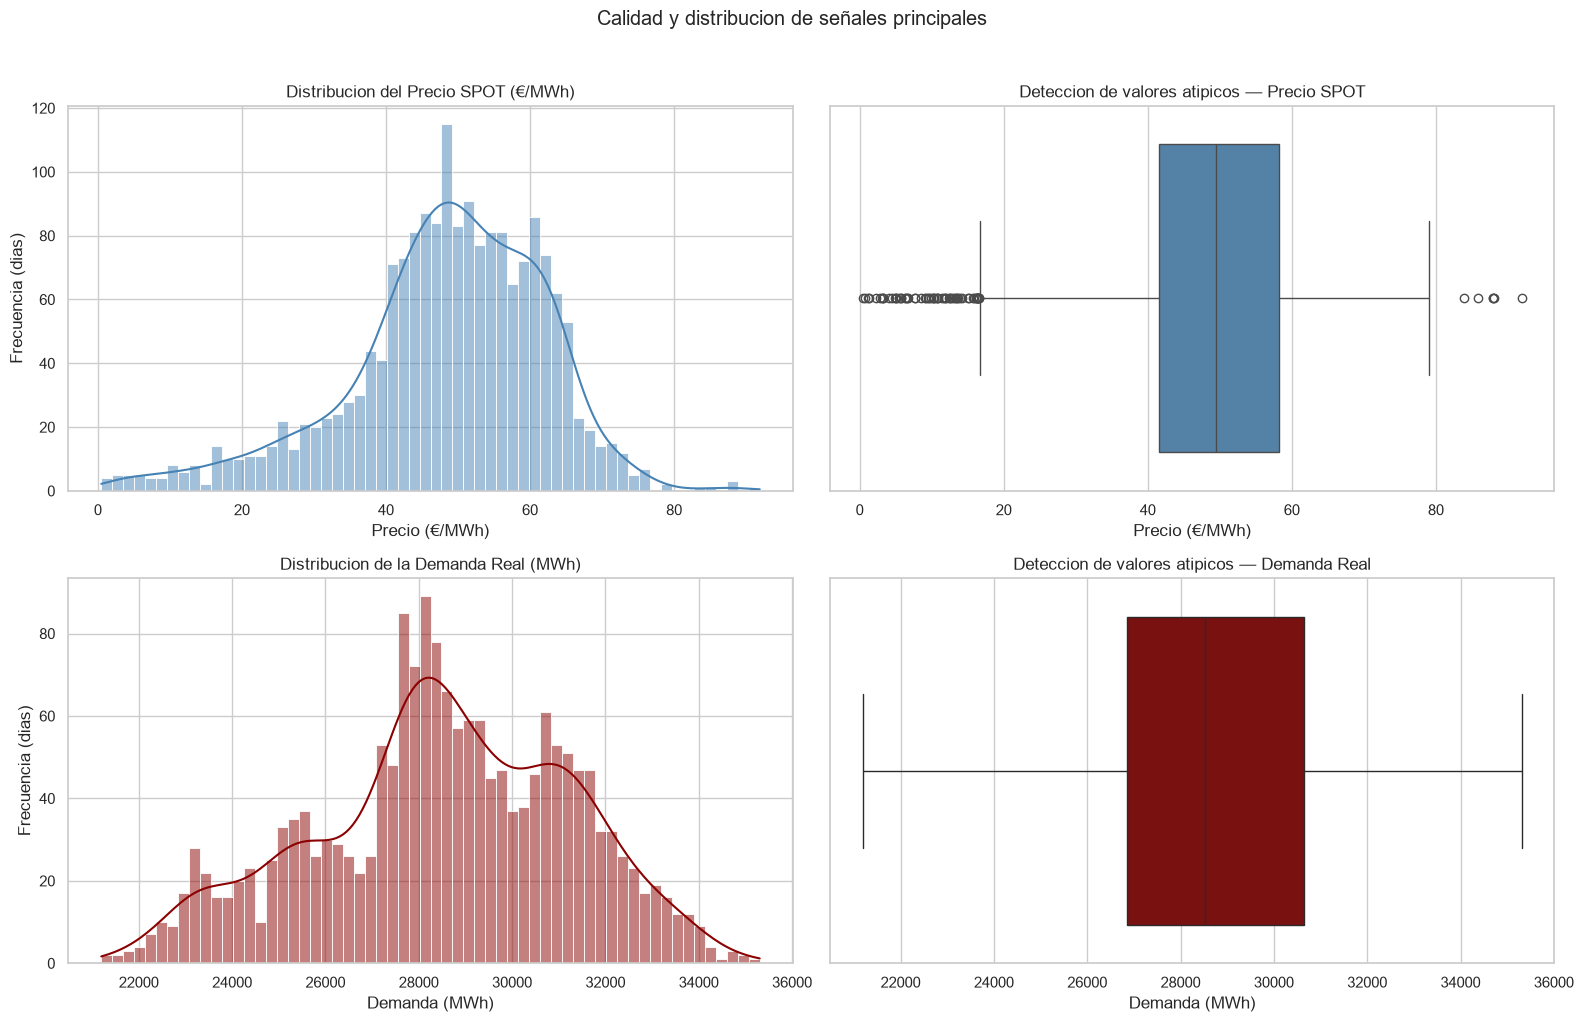

In [20]:
#distribucion estadistica de precio y demanda en paralelo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#histograma de precio
sns.histplot(df_precio['precio_spot'], bins=60, kde=True,
             color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribucion del Precio SPOT (€/MWh)')
axes[0, 0].set_xlabel('Precio (€/MWh)')
axes[0, 0].set_ylabel('Frecuencia (dias)')

#boxplot de precio
sns.boxplot(x=df_precio['precio_spot'], color='steelblue', ax=axes[0, 1])
axes[0, 1].set_title('Deteccion de valores atipicos — Precio SPOT')
axes[0, 1].set_xlabel('Precio (€/MWh)')

#histograma de demanda
sns.histplot(df_demanda['demanda_mwh'], bins=60, kde=True,
             color='darkred', ax=axes[1, 0])
axes[1, 0].set_title('Distribucion de la Demanda Real (MWh)')
axes[1, 0].set_xlabel('Demanda (MWh)')
axes[1, 0].set_ylabel('Frecuencia (dias)')

#boxplot de demanda
sns.boxplot(x=df_demanda['demanda_mwh'], color='darkred', ax=axes[1, 1])
axes[1, 1].set_title('Deteccion de valores atipicos — Demanda Real')
axes[1, 1].set_xlabel('Demanda (MWh)')

plt.suptitle('Calidad y distribucion de señales principales', y=1.02)
plt.tight_layout()
plt.show()

## Segmentación Temporal: Patrones Cíclicos
Análisis del comportamiento del precio y la demanda agrupados por día de la semana,
mes y estación.

In [ ]:
#dataframe unificado con columnas temporales para segmentar
df_seg = pd.concat([df_precio, df_demanda], axis=1).dropna()

#extraer dimensiones temporales del indice para agrupar
df_seg['dia_semana'] = df_seg.index.day_name()   #nombre del dia
df_seg['mes']        = df_seg.index.month         #numero de mes 1-12
df_seg['mes_nombre'] = df_seg.index.month_name()  # nombre del mes

#mapear meses a estaciones en espana
estaciones = {
    12: 'Invierno', 1: 'Invierno', 2: 'Invierno',
    3:  'Primavera', 4: 'Primavera', 5: 'Primavera',
    6:  'Verano',    7: 'Verano',    8: 'Verano',
    9:  'Otoño',    10: 'Otoño',    11: 'Otoño'
}
df_seg['estacion'] = df_seg['mes'].map(estaciones)

print(f"Registros en df_seg: {len(df_seg)}")
display(df_seg.head())

Registros en df_seg: 1825


,precio_spot,demanda_mwh,dia_semana,mes,mes_nombre,estacion
datetime,,,,,,
2014-01-01 23:00:00,25.280833,28191.597222,Wednesday,1,January,Invierno
2014-01-02 23:00:00,39.924167,28465.180556,Thursday,1,January,Invierno
2014-01-03 23:00:00,4.992083,26860.493056,Friday,1,January,Invierno
2014-01-04 23:00:00,4.091667,25333.597222,Saturday,1,January,Invierno
2014-01-05 23:00:00,13.587500,23905.541667,Sunday,1,January,Invierno


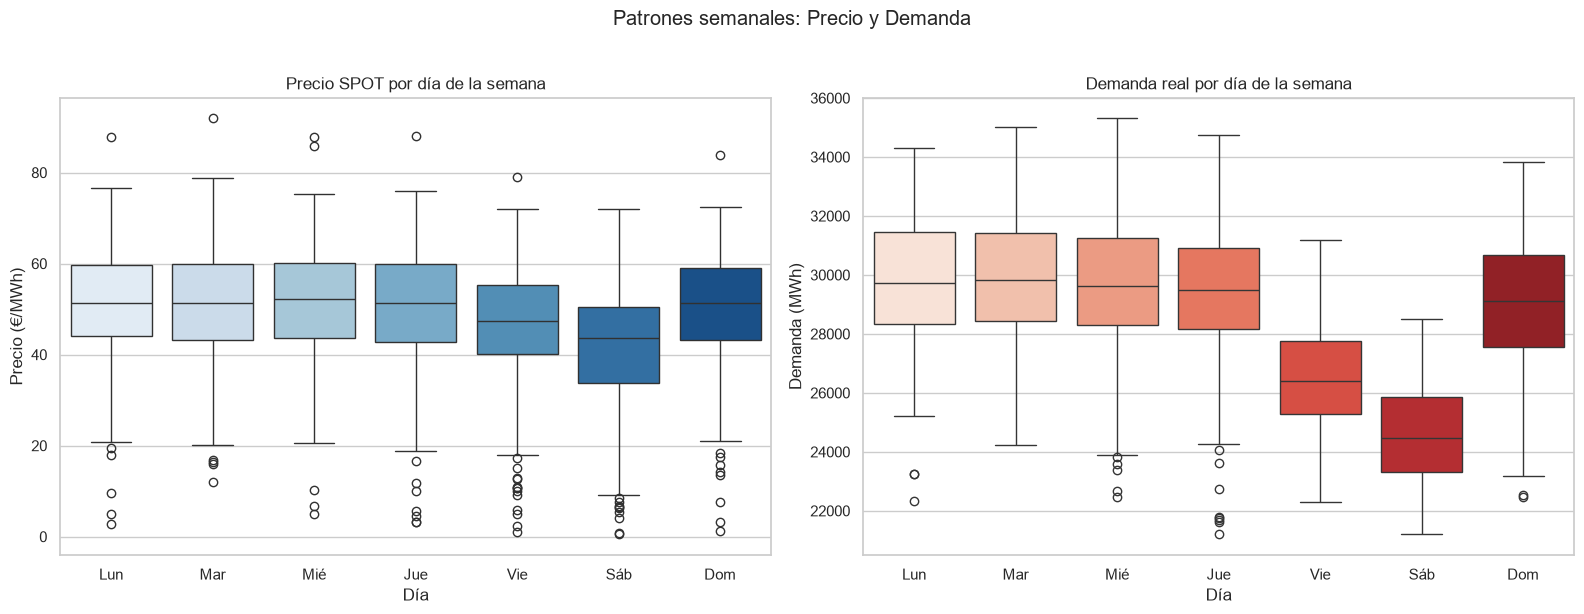

In [22]:
#orden logico de dias para que el grafico no salga alfabetico
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
etiquetas_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#precio por dia de semana
sns.boxplot(data=df_seg, x='dia_semana', y='precio_spot',
            order=orden_dias, palette='Blues', ax=axes[0])
axes[0].set_xticklabels(etiquetas_dias)
axes[0].set_title('Precio SPOT por día de la semana')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Precio (€/MWh)')

#demanda por dia de semana
sns.boxplot(data=df_seg, x='dia_semana', y='demanda_mwh',
            order=orden_dias, palette='Reds', ax=axes[1])
axes[1].set_xticklabels(etiquetas_dias)
axes[1].set_title('Demanda real por día de la semana')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Demanda (MWh)')

plt.suptitle('Patrones semanales: Precio y Demanda', y=1.02)
plt.tight_layout()
plt.show()

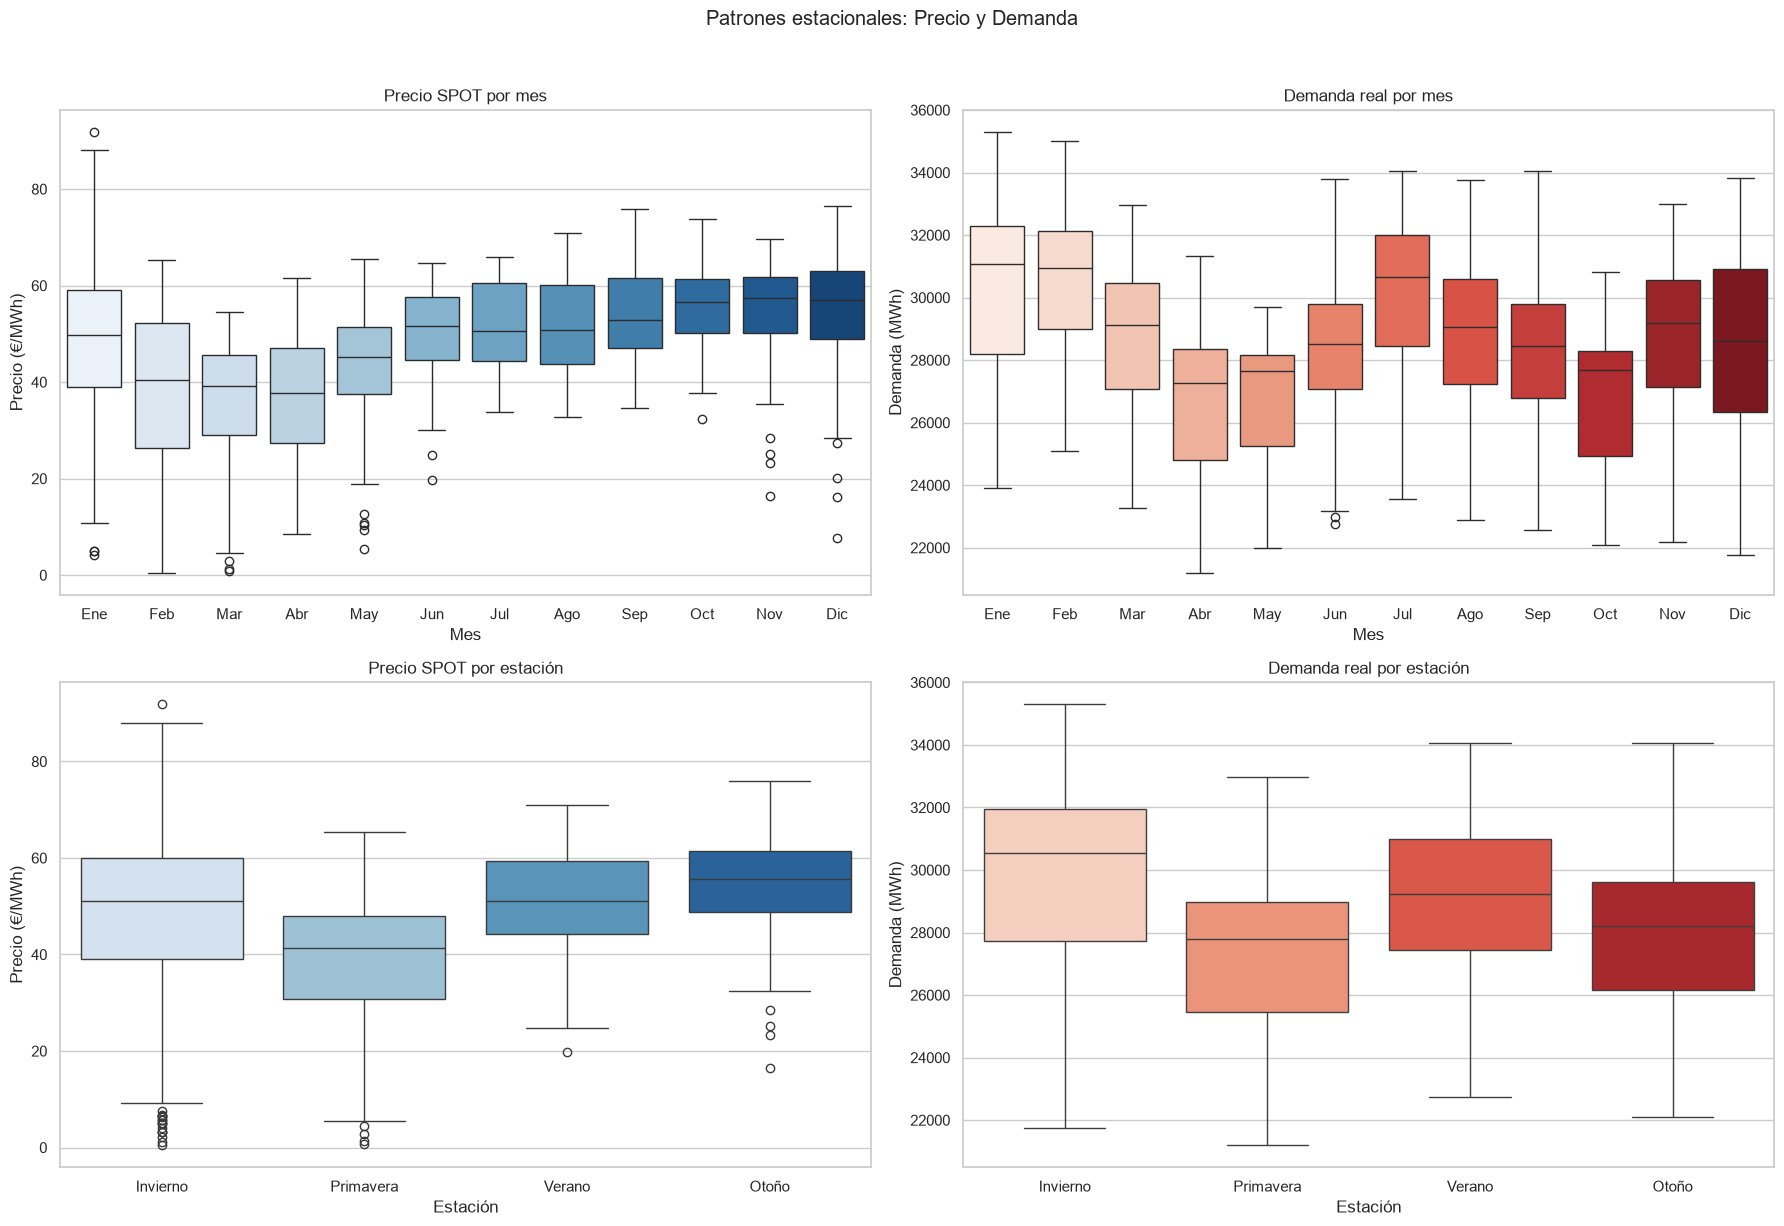

In [23]:
#orden logico de meses
orden_meses = list(range(1, 13))
etiquetas_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                   'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
orden_estaciones = ['Invierno', 'Primavera', 'Verano', 'Otoño']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

#precio por mes
sns.boxplot(data=df_seg, x='mes', y='precio_spot',
            order=orden_meses, palette='Blues', ax=axes[0, 0])
axes[0, 0].set_xticklabels(etiquetas_meses)
axes[0, 0].set_title('Precio SPOT por mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Precio (€/MWh)')

#demanda por mes
sns.boxplot(data=df_seg, x='mes', y='demanda_mwh',
            order=orden_meses, palette='Reds', ax=axes[0, 1])
axes[0, 1].set_xticklabels(etiquetas_meses)
axes[0, 1].set_title('Demanda real por mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Demanda (MWh)')

#precio por estacion
sns.boxplot(data=df_seg, x='estacion', y='precio_spot',
            order=orden_estaciones, palette='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Precio SPOT por estación')
axes[1, 0].set_xlabel('Estación')
axes[1, 0].set_ylabel('Precio (€/MWh)')

#demanda por estacion
sns.boxplot(data=df_seg, x='estacion', y='demanda_mwh',
            order=orden_estaciones, palette='Reds', ax=axes[1, 1])
axes[1, 1].set_title('Demanda real por estación')
axes[1, 1].set_xlabel('Estación')
axes[1, 1].set_ylabel('Demanda (MWh)')

plt.suptitle('Patrones estacionales: Precio y Demanda', y=1.02)
plt.tight_layout()
plt.show()

## Visualización Macroscópica
Aplicación de remuestreo temporal (agrupación diaria y mensual) para reducir el ruido
de los datos diarios y revelar la tendencia general del precio a lo largo de los 5 años.

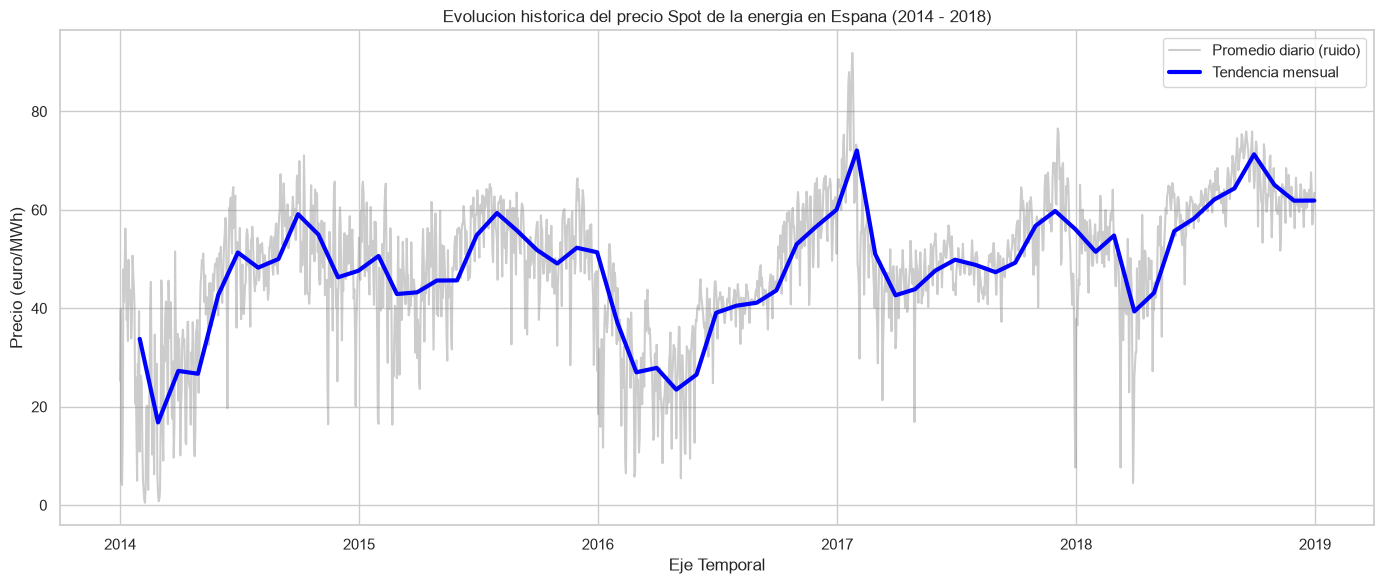

In [24]:
#convertir ruido horario en promedios diarios y mensuales
precio_diario = df_precio['precio_spot'].resample('D').mean()
precio_mensual = df_precio['precio_spot'].resample('ME').mean()

#grafico
plt.figure(figsize=(14, 6))

#pulso diario
plt.plot(precio_diario.index, precio_diario.values, color='gray', alpha=0.4, label='Promedio diario (ruido)')

#tendencia mensual
plt.plot(precio_mensual.index, precio_mensual.values, color='blue', linewidth=3, label='Tendencia mensual')

plt.title('Evolucion historica del precio Spot de la energia en Espana (2014 - 2018)')
plt.ylabel('Precio (euro/MWh)')
plt.xlabel('Eje Temporal')
plt.legend()
plt.tight_layout()
plt.show()

## Análisis Bivariado Temporal (Precio vs Demanda)
Sincronización de las señales macroscópicas de precio y demanda real para identificar la correlación gravitacional entre el consumo físico y el impacto financiero en el mercado SPOT.

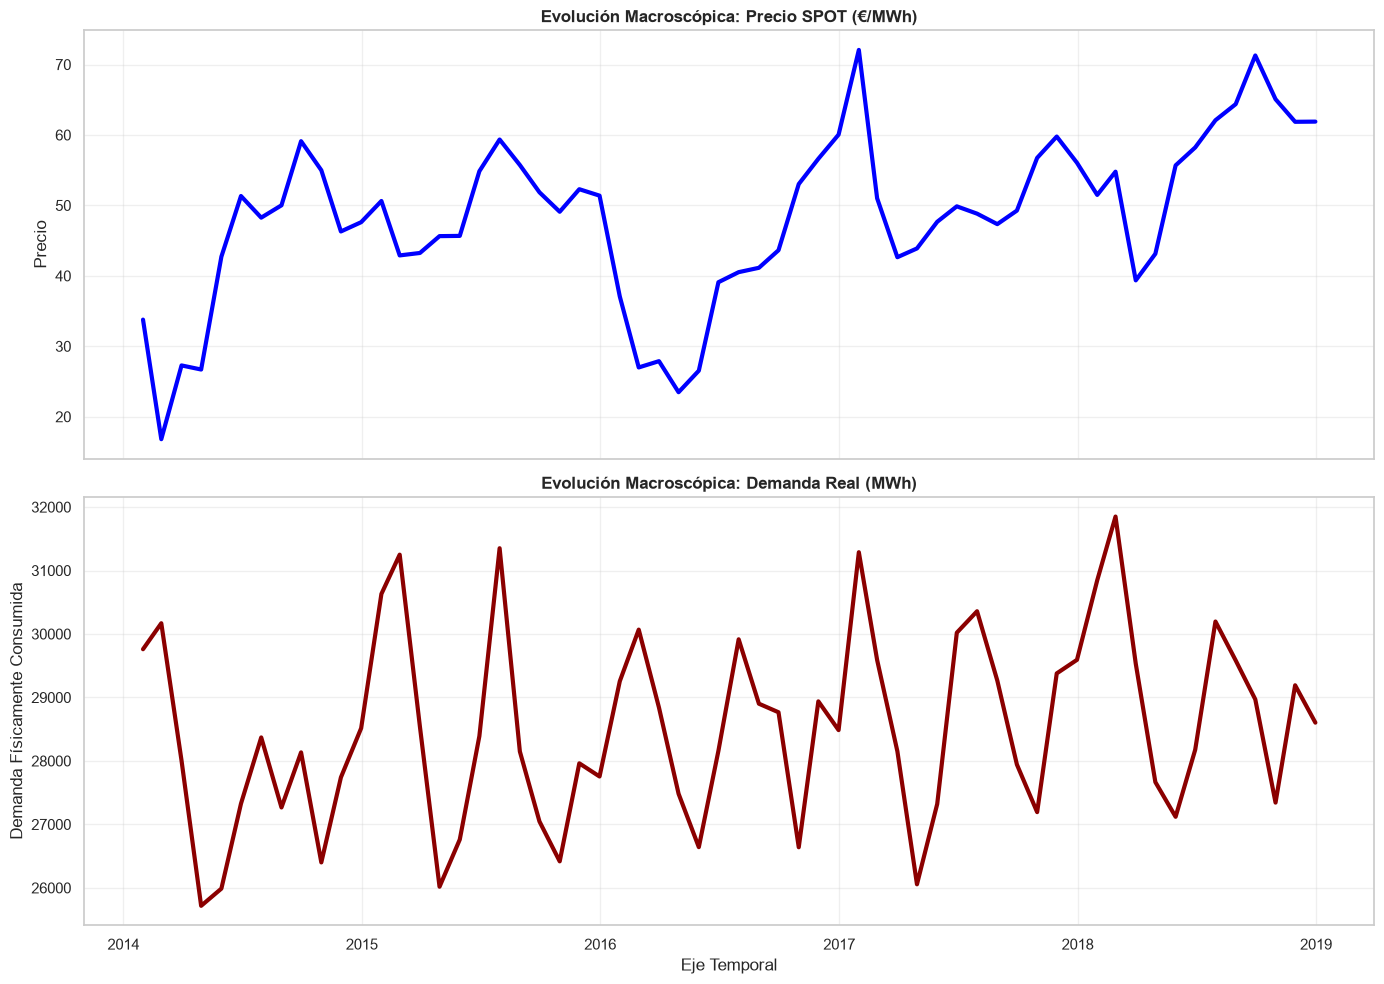

In [25]:
#remuestreo mensual de la demanda
demanda_mensual = df_demanda['demanda_mwh'].resample('ME').mean()

#arquitectura del grafico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

#panel superior
ax1.plot(precio_mensual.index, precio_mensual.values, color='blue', linewidth=3)
ax1.set_title('Evolución Macroscópica: Precio SPOT (€/MWh)', fontweight='bold')
ax1.set_ylabel('Precio')
ax1.grid(True, alpha=0.3)

#panel inferior
ax2.plot(demanda_mensual.index, demanda_mensual.values, color='darkred', linewidth=3)
ax2.set_title('Evolución Macroscópica: Demanda Real (MWh)', fontweight='bold')
ax2.set_ylabel('Demanda Físicamente Consumida')
ax2.set_xlabel('Eje Temporal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Inyección del Factor Climático
Aislamiento de la métrica de generación eólica para identificar el impacto del "Orden de Mérito" y la energía de costo marginal cero sobre los precios finales del mercado.

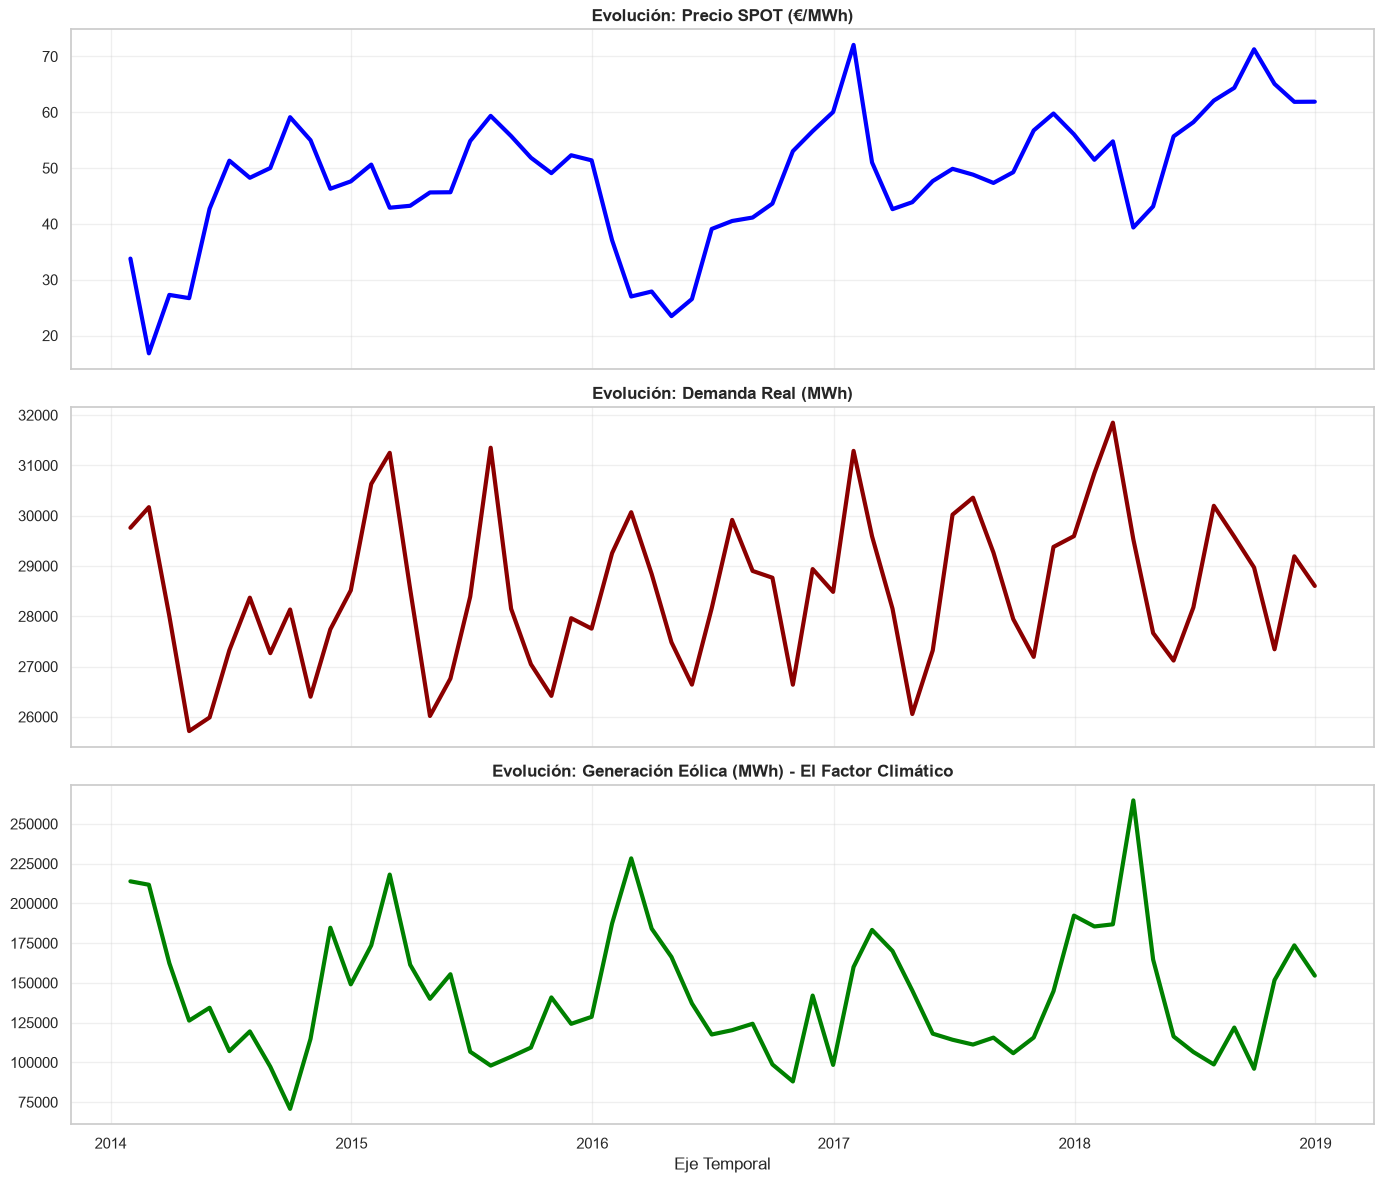

In [26]:
#aislamiento de la generacion eolica (ID 10073)
df_eolica = df_energia[df_energia['id'] == 10073].copy()
df_eolica = df_eolica[['value']].rename(columns={'value': 'generacion_eolica'})

#remuestreo mensual para alinear con las otras señales
eolica_mensual = df_eolica['generacion_eolica'].resample('ME').mean()

#arquitectura del grafico
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

#panel 1
ax1.plot(precio_mensual.index, precio_mensual.values, color='blue', linewidth=3)
ax1.set_title('Evolución: Precio SPOT (€/MWh)', fontweight='bold')
ax1.grid(True, alpha=0.3)

#panel 2
ax2.plot(demanda_mensual.index, demanda_mensual.values, color='darkred', linewidth=3)
ax2.set_title('Evolución: Demanda Real (MWh)', fontweight='bold')
ax2.grid(True, alpha=0.3)

#panel 3
ax3.plot(eolica_mensual.index, eolica_mensual.values, color='green', linewidth=3)
ax3.set_title('Evolución: Generación Eólica (MWh) - El Factor Climático', fontweight='bold')
ax3.set_xlabel('Eje Temporal')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Demostración Matemática: Correlación y Dispersión
Fusión de las señales temporales (remuestreo diario) en un único dataframe para calcular la matriz de Pearson y visualizar la relación inversa mediante un gráfico de dispersión con regresión lineal.

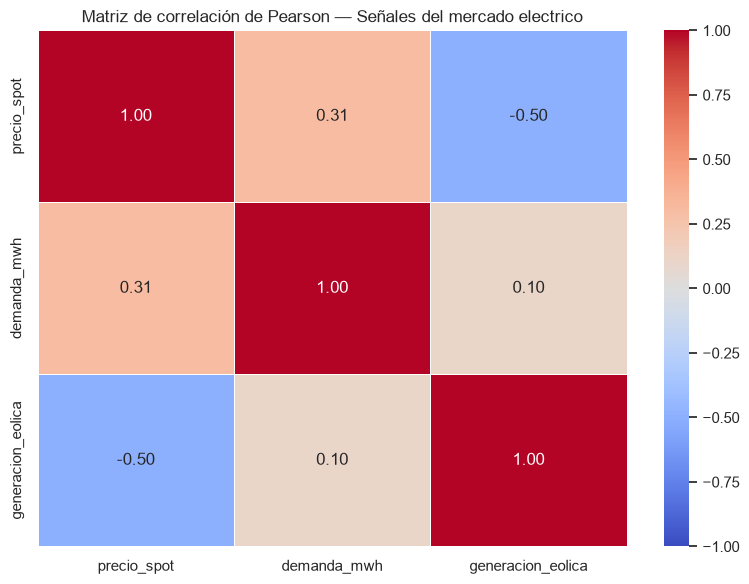

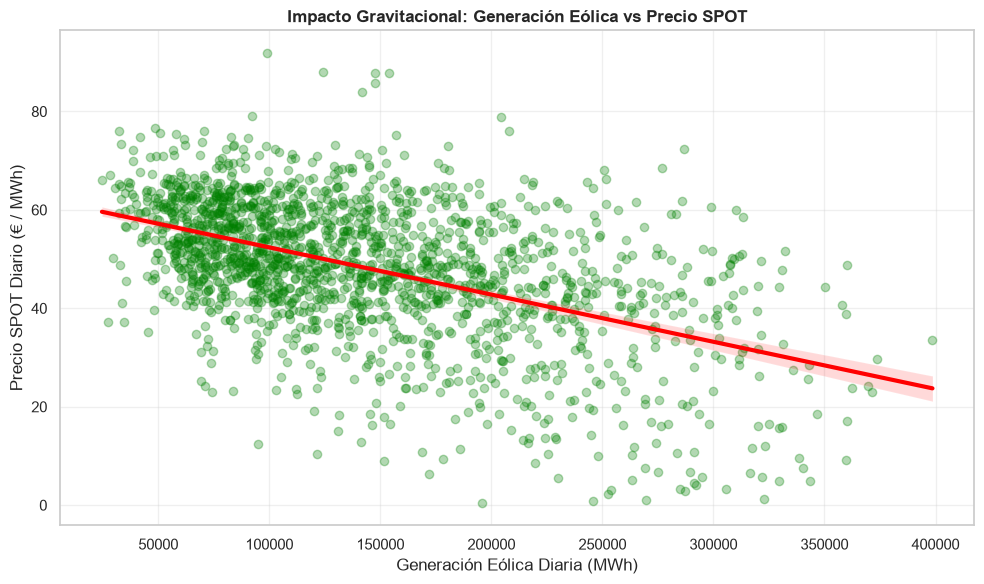

In [27]:
#demostracion matematica viento vs precio

#remuestreo diario
precio_D = df_precio['precio_spot'].resample('D').mean()
demanda_D = df_demanda['demanda_mwh'].resample('D').mean()
eolica_D = df_eolica['generacion_eolica'].resample('D').mean()

#fusion estructural
df_cruce = pd.concat([precio_D, demanda_D, eolica_D], axis=1).dropna()

#calculo de la matriz de correlacion de Pearson
correlacion = df_cruce.corr()

#visualizar como heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Matriz de correlación de Pearson — Señales del mercado electrico')
plt.tight_layout()
plt.show()

#arquitectura del grafico de dispersion
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cruce, x='generacion_eolica', y='precio_spot',
            scatter_kws={'alpha':0.3, 'color':'green'},
            line_kws={'color':'red', 'linewidth':3})

plt.title('Impacto Gravitacional: Generación Eólica vs Precio SPOT', fontweight='bold')
plt.xlabel('Generación Eólica Diaria (MWh)')
plt.ylabel('Precio SPOT Diario (€ / MWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pairplot: Forma Visual de las Correlaciones
Complemento visual de la matriz de Pearson. Muestra la forma geométrica
de cada relación — algo que el coeficiente numérico no puede revelar.

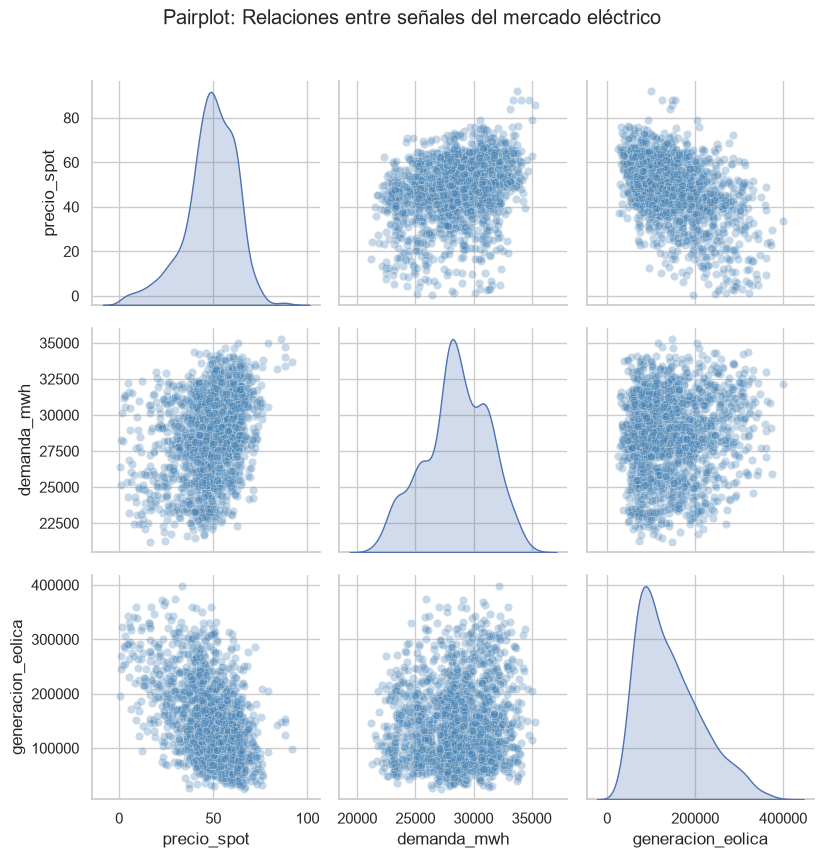

In [28]:
#pairplot sobre df_cruce
sns.pairplot(
    df_cruce,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 'color': 'steelblue'},
    height=2.8
)

plt.suptitle('Pairplot: Relaciones entre señales del mercado eléctrico', y=1.02)
plt.tight_layout()
plt.show()

## Conclusiones del Análisis Exploratorio

### ¿Qué determina el precio de la energía en España?

**1. Cuando hay más viento, la energía es más barata**
La correlación entre generación eólica y precio SPOT es -0.50 — la más fuerte
del dataset. La lógica es simple: la energía eólica no tiene costo de combustible,
entonces cuando hay mucho viento el mercado se llena de energía barata y el precio baja.
Esto se confirma visualmente en el regplot y en el pairplot.

**2. La demanda sigue patrones predecibles pero no mueve el precio sola**
La correlación demanda-precio es 0.31 y demanda-eólica es apenas 0.10.
La demanda sube y baja de forma ordenada:
- **Lunes a jueves**: ~29,500–30,000 MWh de consumo sostenido
- **Viernes y sábado**: caída progresiva hasta 24,685 MWh (mínimo semanal)
- **Domingo**: se recupera a ~29,000 MWh
- **Invierno y verano** tienen el mayor consumo (~29,800 y ~29,000 MWh),
  primavera es el valle más bajo del año con ~27,300 MWh

Pero que haya más consumo no significa que el precio suba — lo que mueve
el precio es si hay suficiente energía barata para cubrirlo.

**3. Primavera es la estación más barata, otoño la más cara**
Primavera promedia 38.79 €/MWh — no porque se consuma menos, sino porque
es la época más ventosa de España. Otoño llega a 55.40 €/MWh porque
la generación eólica cae y la demanda industrial sigue activa.

**4. El histograma de demanda tenía dos picos por una razón**
En el análisis univariado se vio una distribución bimodal en la demanda.
La segmentación lo explicó: son dos regímenes normales del sistema — invierno
con alto consumo por calefacción y primavera con bajo consumo por clima templado.

**5. Los datos son diarios y están completos**
Cada registro representa un día, con cobertura continua entre 2014 y 2018.
Sin huecos, sin nulos. La demanda termina un día antes que el precio
(30 vs 31 de diciembre de 2018), diferencia menor documentada en el análisis.